<a href="https://colab.research.google.com/github/IsaacB04/-dar-es-salaam-urban-heat-risk/blob/main/notebooks/Dar_es_Salaam_Heat_Risk_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dar es Salaam Urban Heat Risk Assessment

This notebook implements the thesis workflow for urban heat-risk assessment in Dar es Salaam using the **Hazard–Exposure–Vulnerability (HEV)** framework.

### Workflow
- 11 spatial indicators grouped into Hazard, Exposure and Vulnerability
- common raster grid based on the LST reference raster
- PCA-derived indicator weighting
- multiplicative heat risk: **H × E × V**
- K-means heat-risk typologies
- K selection using Elbow, Silhouette and ARI stability
- final K = 4
- five Jenks heat-risk classes
- leave-one-indicator-out sensitivity analysis
- GeoTIFF and CSV export

> **Reference-grid note:** the LST raster is stored in EPSG:4326, so its resolution is expressed in degrees. The script therefore uses the LST raster itself as the exact reference grid rather than incorrectly comparing its degree-based resolution to 30 metres.


In [26]:
"""
Dar es Salaam Urban Heat Risk Assessment
========================================

Reproducible thesis workflow based on the Hazard–Exposure–Vulnerability
(HEV) framework.

Workflow
--------
1. Load the 11 thesis indicators.
2. Use the LST raster as the reference analysis grid.
3. Align all other rasters to that exact grid.
4. Build PCA-weighted Hazard, Exposure and Vulnerability indices.
5. Compute continuous heat risk as H × E × V.
6. Select K using Elbow, Silhouette and ARI stability.
7. Apply the thesis K=4 solution.
8. Classify continuous risk into five Jenks classes.
9. Perform leave-one-indicator-out sensitivity analysis.
10. Export rasters and tables.

Important
---------
The reference LST raster is stored in EPSG:4326. Therefore its pixel
resolution is expressed in degrees, not metres. The code does NOT compare
the EPSG:4326 resolution numerically to 30 metres. Instead, the LST raster
itself defines the exact common analysis grid used by all indicators.

The thesis describes this common analysis grid as 30 m. The 30 m value is
therefore retained only where a pixel-area estimate is required.
"""


'\nDar es Salaam Urban Heat Risk Assessment\n========================================\n\nReproducible thesis workflow based on the Hazard–Exposure–Vulnerability\n(HEV) framework.\n\nWorkflow\n--------\n1. Load the 11 thesis indicators.\n2. Use the LST raster as the reference analysis grid.\n3. Align all other rasters to that exact grid.\n4. Build PCA-weighted Hazard, Exposure and Vulnerability indices.\n5. Compute continuous heat risk as H × E × V.\n6. Select K using Elbow, Silhouette and ARI stability.\n7. Apply the thesis K=4 solution.\n8. Classify continuous risk into five Jenks classes.\n9. Perform leave-one-indicator-out sensitivity analysis.\n10. Export rasters and tables.\n\nImportant\n---------\nThe reference LST raster is stored in EPSG:4326. Therefore its pixel\nresolution is expressed in degrees, not metres. The code does NOT compare\nthe EPSG:4326 resolution numerically to 30 metres. Instead, the LST raster\nitself defines the exact common analysis grid used by all indicato

In [27]:
# 1. SETUP AND CONFIGURATION

import os
from pathlib import Path

import numpy as np
import pandas as pd
import rasterio
from rasterio.enums import Resampling
from rasterio.warp import reproject

import matplotlib.pyplot as plt
import mapclassify as mc

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler


# Optional Google Colab support
try:
    from google.colab import drive
    drive.mount("/content/drive")
except ImportError:
    pass

# Paths

DATA_DIR = Path(
    os.environ.get(
        "UHI_DATA_DIR",
        "/content/drive/MyDrive/GIS_Projects/UHI_Dar/"
        "machine_learning/all_drivers/drivers",
    )
)

OUTPUT_DIR = DATA_DIR / "outputs_risk_kmeans"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# Analysis settings

RANDOM_STATE = 42
MAX_ITERS = 300

# Common analysis grid is 30 m
# This value is used only for the approximate pixel-area calculation
GRID_SIZE_M = 30.0

MAX_K_SELECTION_SAMPLES = 20_000

K_MIN = 2
K_MAX = 10

# Candidate solutions examined around the elbow
CANDIDATE_K = [4, 5, 6]

# Final K value
FINAL_K = 4

# Five heat-risk classes
N_RISK_CLASSES = 5
RISK_CLASS_LABELS = [
    "Very Low",
    "Low",
    "Medium",
    "High",
    "Very High",
]

# Input raster names

LAYER_FILES = {
    "lst": "lst.tif",
    "hot_days": "hot_days.tif",
    "ndbi": "ndbi.tif",
    "population_density": "population_density.tif",
    "sensitive_population_density": "sensitive_population_density.tif",
    "dist_health": "distance_to_health_facilities.tif",
    "dist_parks": "distance_to_parks.tif",
    "dist_transit": "distance_to_public_transport.tif",
    "rwi": "rwi.tif",
    "tree_cover": "tree_cover.tif",
    "dist_water": "distance_to_waterbodies.tif",
}

# HEV grouping

GROUPS = {
    "Hazard": [
        "lst",
        "hot_days",
    ],
    "Exposure": [
        "ndbi",
        "population_density",
    ],
    "Vulnerability": [
        "dist_water",
        "sensitive_population_density",
        "dist_health",
        "dist_parks",
        "dist_transit",
        "rwi",
        "tree_cover",
    ],
}


LAYER_LABELS = {
    "lst": "Land Surface Temperature",
    "hot_days": "Number of hot days",
    "ndbi": "NDBI",
    "population_density": "Population density",
    "sensitive_population_density": "Sensitive population density",
    "dist_health": "Distance to health facilities",
    "dist_parks": "Distance to parks",
    "dist_transit": "Distance to public transport",
    "rwi": "Relative Wealth Index",
    "tree_cover": "Tree cover",
    "dist_water": "Distance to the ocean",
}


# Continuous indicators use bilinear resampling
# Tree cover which is binary uses nearest-neighbour preserves its class values
RESAMPLING_METHODS = {
    key: Resampling.bilinear
    for key in LAYER_FILES
}
RESAMPLING_METHODS["tree_cover"] = Resampling.nearest


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
# 2. RASTER LOADING AND REFERENCE GRID

def read_raster(path):
    """Read a single-band raster and return data, invalid mask and profile."""
    with rasterio.open(path) as src:
        array = src.read(1).astype("float32", copy=False)
        profile = src.profile.copy()
        nodata = src.nodata

    invalid = ~np.isfinite(array)

    if nodata is not None:
        invalid |= np.isclose(array, nodata)

    return array, invalid, profile


def reproject_to_reference(src_path, ref_profile, resampling):
    """
    Align a raster to the exact reference grid.

    The destination uses the reference raster's:
    - CRS
    - transform
    - width
    - height
    """
    with rasterio.open(src_path) as src:
        source = src.read(1).astype("float32", copy=False)

        invalid = ~np.isfinite(source)

        if src.nodata is not None:
            invalid |= np.isclose(source, src.nodata)

        source[invalid] = np.nan

        destination = np.full(
            (ref_profile["height"], ref_profile["width"]),
            np.nan,
            dtype="float32",
        )

        reproject(
            source=source,
            destination=destination,
            src_transform=src.transform,
            src_crs=src.crs,
            src_nodata=np.nan,
            dst_transform=ref_profile["transform"],
            dst_crs=ref_profile["crs"],
            dst_nodata=np.nan,
            resampling=resampling,
            init_dest_nodata=True,
        )

    return destination, ~np.isfinite(destination)


# Locate all required rasters

paths = {
    key: DATA_DIR / filename
    for key, filename in LAYER_FILES.items()
}

missing = [
    str(path)
    for path in paths.values()
    if not path.exists()
]

if missing:
    raise FileNotFoundError(
        "The following raster files are missing:\n"
        + "\n".join(missing)
    )


# LST is the reference analysis grid

REFERENCE_KEY = "lst"
REFERENCE_RASTER = paths[REFERENCE_KEY]

ref_array, ref_mask, ref_profile = read_raster(REFERENCE_RASTER)

REF_CRS = ref_profile["crs"]
REF_TRANSFORM = ref_profile["transform"]
REF_WIDTH = ref_profile["width"]
REF_HEIGHT = ref_profile["height"]
REF_SHAPE = (REF_HEIGHT, REF_WIDTH)

print(f"Reference raster : {REFERENCE_RASTER.name}")
print(f"CRS              : {REF_CRS}")
print(
    "Resolution       : "
    f"{abs(REF_TRANSFORM.a):.12f} × "
    f"{abs(REF_TRANSFORM.e):.12f}"
)
print(f"Shape            : {REF_HEIGHT} × {REF_WIDTH}")

if REF_CRS is None:
    raise ValueError("The reference LST raster has no CRS.")

if REF_CRS.to_epsg() != 4326:
    raise ValueError(
        f"Expected the reference LST raster to use EPSG:4326, "
        f"but found {REF_CRS}."
    )

print(
    "\nThe LST raster is used as the exact reference grid. "
    "All other indicators will be aligned to this grid."
)

# Align all indicators

data_arrays = {
    "lst": ref_array
}

masks = {
    "lst": ref_mask
}

for key, path in paths.items():
    if key == REFERENCE_KEY:
        continue

    array, mask = reproject_to_reference(
        path,
        ref_profile,
        RESAMPLING_METHODS[key],
    )

    data_arrays[key] = array
    masks[key] = mask


# Common valid-data mask

all_valid = np.ones(REF_SHAPE, dtype=bool)

for mask in masks.values():
    all_valid &= ~mask

if not np.any(all_valid):
    raise ValueError(
        "No pixels contain valid data across all 11 indicators."
    )

print(f"Valid pixels used in analysis: {all_valid.sum():,}")


# Confirm identical array dimensions.
for key, array in data_arrays.items():
    if array.shape != REF_SHAPE:
        raise ValueError(
            f"{key} does not match the reference raster shape."
        )

print("All 11 indicators are aligned to the reference grid.")


Reference raster : lst.tif
CRS              : EPSG:4326
Resolution       : 0.000269494585 × 0.000269494585
Shape            : 2285 × 2029

The LST raster is used as the exact reference grid. All other indicators will be aligned to this grid.
Valid pixels used in analysis: 1,839,111
All 11 indicators are aligned to the reference grid.


In [29]:
# 3. PCA-DERIVED HEV INDICES
def minmax01(values):
    """Normalize values to the [0, 1] range."""
    values = np.asarray(values, dtype="float32")

    vmin = np.nanmin(values)
    vmax = np.nanmax(values)

    if not np.isfinite(vmin) or not np.isfinite(vmax):
        raise ValueError(
            "Cannot normalize an array with no finite values."
        )

    if np.isclose(vmax, vmin):
        return np.zeros_like(values, dtype="float32")

    return (
        (values - vmin) / (vmax - vmin)
    ).astype("float32")


# Flatten only pixels that are valid across all indicators
df_all = pd.DataFrame({
    key: data_arrays[key][all_valid].astype(
        "float32",
        copy=False,
    )
    for key in LAYER_FILES
})

if not np.isfinite(df_all.to_numpy()).all():
    raise ValueError(
        "Unexpected invalid values remain inside the common valid mask."
    )


def build_group_index(df, columns):
    """
    Build one HEV component using the thesis PCA procedure.

    1. Standardize indicators.
    2. Fit PCA.
    3. Use absolute PC1 loadings.
    4. Normalize loadings to obtain weights.
    5. Calculate weighted sum using normalized indicators.
    6. Normalize the component index to [0, 1].
    """
    columns = [
        column
        for column in columns
        if column in df.columns
    ]

    if not columns:
        raise ValueError(
            "No indicators are available for this HEV component."
        )

    X = df[columns].to_numpy(dtype="float32")

    # Standardization for PCA
    scaler = StandardScaler()
    X_standardized = scaler.fit_transform(X)

    # First principal component
    pca = PCA(
        n_components=1,
        random_state=RANDOM_STATE,
    )
    pca.fit(X_standardized)

    loadings = pca.components_[0]

    # Absolute PC1 loadings become the indicator weights
    weights = np.abs(loadings)
    weights /= weights.sum()

    # Apply the weights to normalized indicators
    X_normalized = np.column_stack([
        minmax01(X[:, i])
        for i in range(X.shape[1])
    ])

    weighted_sum = (
        X_normalized * weights
    ).sum(axis=1)

    component = minmax01(weighted_sum)

    weights_table = pd.DataFrame({
        "indicator": columns,
        "weight": weights,
    })

    weights_table["PC1_explained_variance_ratio"] = (
        float(pca.explained_variance_ratio_[0])
    )

    return component, weights_table


component_indices = {}
component_weights_tables = {}

for group_name, columns in GROUPS.items():
    component, weights_table = build_group_index(
        df_all,
        columns,
    )

    component_indices[group_name] = component
    component_weights_tables[group_name] = weights_table


print("\nPCA-derived indicator weights")

for group_name, table in component_weights_tables.items():
    print(f"\n{group_name}")
    print(table.round(4).to_string(index=False))
    print(
        f"Weight sum: "
        f"{table['weight'].sum():.6f}"
    )


# HEV component indices

H = component_indices["Hazard"]
E = component_indices["Exposure"]
V = component_indices["Vulnerability"]


# Multiplicative heat risk

# Risk = H × E × V
# H, E and V are already normalized to [0, 1].
risk_flat = (
    H * E * V
).astype("float32")


# Convert HEV indices back to rasters

H_r = np.full(
    REF_SHAPE,
    np.nan,
    dtype="float32",
)

E_r = np.full(
    REF_SHAPE,
    np.nan,
    dtype="float32",
)

V_r = np.full(
    REF_SHAPE,
    np.nan,
    dtype="float32",
)

Risk_r = np.full(
    REF_SHAPE,
    np.nan,
    dtype="float32",
)

H_r[all_valid] = H
E_r[all_valid] = E
V_r[all_valid] = V
Risk_r[all_valid] = risk_flat



PCA-derived indicator weights

Hazard
indicator  weight  PC1_explained_variance_ratio
      lst     0.5                         0.532
 hot_days     0.5                         0.532
Weight sum: 1.000000

Exposure
         indicator  weight  PC1_explained_variance_ratio
              ndbi     0.5                        0.6568
population_density     0.5                        0.6568
Weight sum: 1.000000

Vulnerability
                   indicator  weight  PC1_explained_variance_ratio
                  dist_water  0.0029                        0.4867
sensitive_population_density  0.1252                        0.4867
                 dist_health  0.2103                        0.4867
                  dist_parks  0.2007                        0.4867
                dist_transit  0.2085                        0.4867
                         rwi  0.2183                        0.4867
                  tree_cover  0.0341                        0.4867
Weight sum: 1.000000



Pixels available for clustering: 1,839,111
Pixels used for K selection: 20,000

K-selection results
 K  Inertia  Silhouette
 2 804.9720      0.4347
 3 607.5256      0.3329
 4 493.9488      0.3071
 5 398.2772      0.3361
 6 354.1619      0.3289
 7 318.5521      0.2971
 8 286.8333      0.2851
 9 264.5497      0.2811
10 243.6416      0.2896


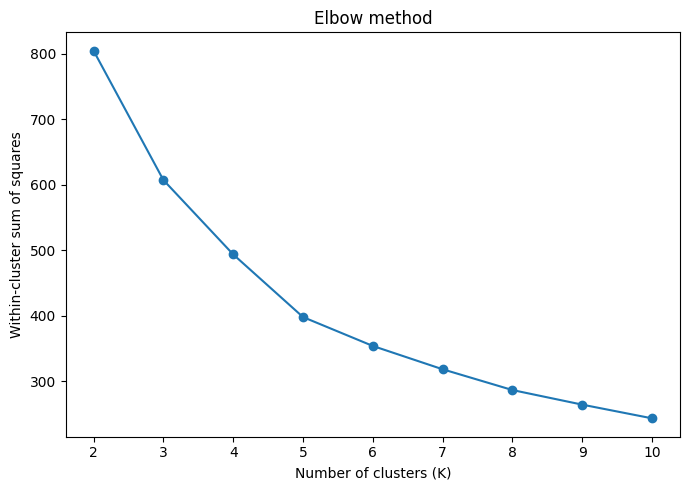

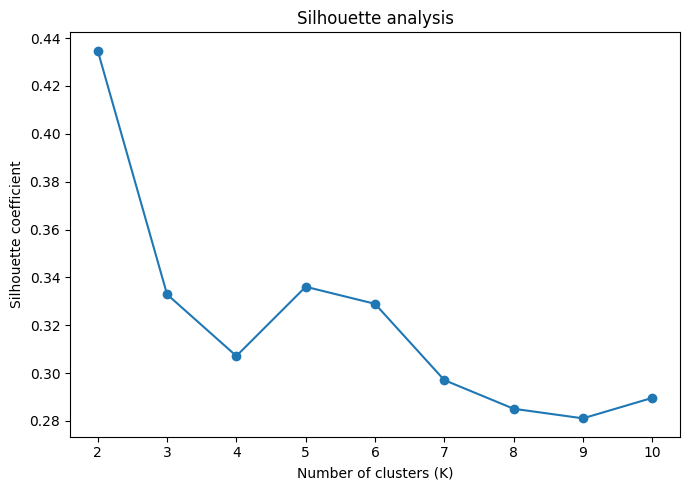


Candidate K stability
   Silhouette_mean  ARI_stability_mean
K                                     
4           0.3072              0.9949
5           0.3358              0.9881
6           0.3290              0.9856

Final K used in the thesis: 4


In [30]:
# 4. K-MEANS CLUSTER SELECTION

def spatial_stratified_sample(
    valid_mask,
    max_samples,
    random_state,
    n_row_blocks=10,
    n_col_blocks=10,
):
    """
    Draw a spatially distributed random sample.

    If the number of valid pixels is <= max_samples, all pixels are used.
    Otherwise, the raster is divided into spatial blocks and samples are
    drawn from each block.
    """
    rows, cols = np.where(valid_mask)
    n = len(rows)

    if n <= max_samples:
        return np.arange(n)

    height, width = valid_mask.shape

    row_blocks = np.minimum(
        (rows * n_row_blocks) // height,
        n_row_blocks - 1,
    )

    col_blocks = np.minimum(
        (cols * n_col_blocks) // width,
        n_col_blocks - 1,
    )

    strata = (
        row_blocks * n_col_blocks
        + col_blocks
    )

    rng = np.random.default_rng(random_state)

    selected = []

    unique_strata = np.unique(strata)

    quota = max_samples // len(unique_strata)

    for stratum in unique_strata:
        candidates = np.flatnonzero(
            strata == stratum
        )

        if len(candidates) <= quota:
            selected.extend(
                candidates.tolist()
            )
        else:
            selected.extend(
                rng.choice(
                    candidates,
                    size=quota,
                    replace=False,
                ).tolist()
            )

    selected = np.asarray(
        selected,
        dtype=int,
    )

    # Fill any remaining positions randomly.
    if len(selected) < max_samples:
        remaining = np.setdiff1d(
            np.arange(n),
            selected,
            assume_unique=False,
        )

        extra = rng.choice(
            remaining,
            size=min(
                max_samples - len(selected),
                len(remaining),
            ),
            replace=False,
        )

        selected = np.concatenate(
            [selected, extra]
        )

    return selected


# Feature matrix for clustering.
X_all = np.column_stack([
    H,
    E,
    V,
]).astype("float32")


sample_indices = spatial_stratified_sample(
    all_valid,
    max_samples=MAX_K_SELECTION_SAMPLES,
    random_state=RANDOM_STATE,
)

X_sample = X_all[sample_indices]

print(
    f"\nPixels available for clustering: "
    f"{len(X_all):,}"
)

print(
    f"Pixels used for K selection: "
    f"{len(X_sample):,}"
)


# Elbow and Silhouette analysis: K = 2–10

Ks = list(range(K_MIN, K_MAX + 1))

inertias = []
silhouettes = []

for k in Ks:
    model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10,
        max_iter=MAX_ITERS,
    )

    labels = model.fit_predict(
        X_sample
    )

    inertias.append(
        model.inertia_
    )

    silhouettes.append(
        silhouette_score(
            X_sample,
            labels,
            sample_size=min(
                5000,
                len(X_sample),
            ),
            random_state=RANDOM_STATE,
        )
    )


k_selection = pd.DataFrame({
    "K": Ks,
    "Inertia": inertias,
    "Silhouette": silhouettes,
})

print("\nK-selection results")
print(k_selection.round(4).to_string(index=False))


# Elbow plot

plt.figure(figsize=(7, 5))
plt.plot(
    k_selection["K"],
    k_selection["Inertia"],
    marker="o",
)
plt.xlabel("Number of clusters (K)")
plt.ylabel("Within-cluster sum of squares")
plt.title("Elbow method")
plt.xticks(Ks)
plt.tight_layout()
plt.show()


# Silhouette plot

plt.figure(figsize=(7, 5))
plt.plot(
    k_selection["K"],
    k_selection["Silhouette"],
    marker="o",
)
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette coefficient")
plt.title("Silhouette analysis")
plt.xticks(Ks)
plt.tight_layout()
plt.show()


# Stability around the candidate solutions K = 4, 5, 6

stability_rows = []

for k in CANDIDATE_K:
    seed_labels = []

    for seed in [0, 1, 2, 3, 4]:
        model = KMeans(
            n_clusters=k,
            random_state=seed,
            n_init=10,
            max_iter=MAX_ITERS,
        )

        seed_labels.append(
            model.fit_predict(X_sample)
        )

    aris = [
        adjusted_rand_score(
            seed_labels[i],
            seed_labels[j],
        )
        for i in range(len(seed_labels))
        for j in range(i + 1, len(seed_labels))
    ]

    silhouette_values = [
        silhouette_score(
            X_sample,
            labels,
            sample_size=min(
                5000,
                len(X_sample),
            ),
            random_state=RANDOM_STATE,
        )
        for labels in seed_labels
    ]

    stability_rows.append({
        "K": k,
        "Silhouette_mean": np.mean(
            silhouette_values
        ),
        "ARI_stability_mean": np.mean(
            aris
        ),
    })


k_candidates = pd.DataFrame(
    stability_rows
).set_index("K")

print("\nCandidate K stability")
print(
    k_candidates.round(4).to_string()
)

print(
    f"\nFinal K used in the thesis: {FINAL_K}"
)



K=4 cluster summary
 Cluster                                         Profile  Area_share_%  Hazard_mean  Exposure_mean  Vulnerability_mean  Risk_mean  Centroid_H  Centroid_E  Centroid_V      zH      zE      zV
       1   Low Hazard – Low Exposure – Low Vulnerability       32.3854       0.4039         0.3090              0.1935     0.0242      0.4039      0.3090      0.1936 -0.3738 -0.0471 -0.7234
       2 High Hazard – High Exposure – Low Vulnerability       26.5884       0.6450         0.3890              0.2023     0.0490      0.6449      0.3889      0.2025  1.2088  0.7717 -0.6837
       3  Low Hazard – Low Exposure – High Vulnerability       21.9024       0.4030         0.2680              0.4489     0.0498      0.4025      0.2679      0.4493 -0.3829 -0.4677  0.4200
       4  Low Hazard – Low Exposure – High Vulnerability       19.1238       0.3674         0.2686              0.7354     0.0730      0.3675      0.2686      0.7356 -0.6131 -0.4605  1.6999


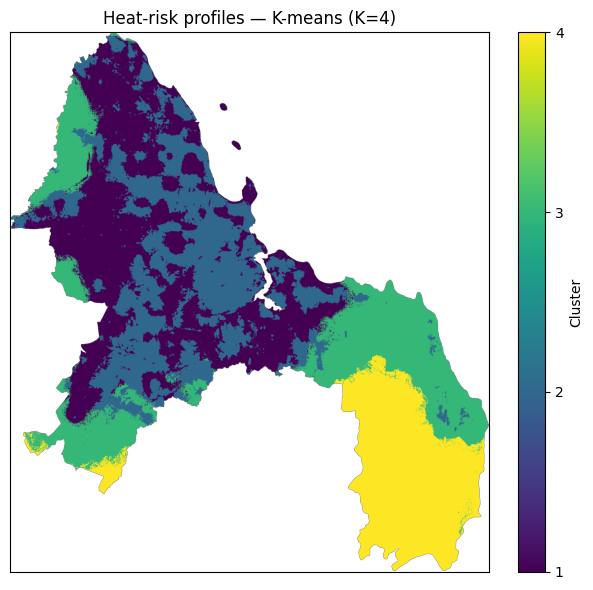

In [31]:
# 5. FINAL K = 4 HEAT-RISK PROFILES

kmeans_final = KMeans(
    n_clusters=FINAL_K,
    random_state=RANDOM_STATE,
    n_init=10,
    max_iter=MAX_ITERS,
)

raw_labels = kmeans_final.fit_predict(
    X_all
)

centroids = kmeans_final.cluster_centers_


# Centroid interpretation

global_mean = np.array([
    H.mean(),
    E.mean(),
    V.mean(),
])

global_std = np.array([
    H.std(),
    E.std(),
    V.std(),
])

safe_std = np.where(
    global_std == 0,
    1.0,
    global_std,
)

centroids_z = (
    centroids - global_mean
) / safe_std


def high_low_label(z_values):
    """Describe each HEV centroid dimension relative to its global mean."""
    tags = [
        "High" if value >= 0 else "Low"
        for value in z_values
    ]

    return (
        f"{tags[0]} Hazard – "
        f"{tags[1]} Exposure – "
        f"{tags[2]} Vulnerability"
    )


raw_cluster_labels = {
    cluster_id: high_low_label(
        centroids_z[cluster_id]
    )
    for cluster_id in range(FINAL_K)
}


# Stable cluster numbering by mean heat risk

risk_means = [
    (
        cluster_id,
        risk_flat[
            raw_labels == cluster_id
        ].mean(),
    )
    for cluster_id in range(FINAL_K)
]

risk_means.sort(
    key=lambda item: item[1]
)

raw_to_class = {
    raw_id: new_id + 1
    for new_id, (raw_id, _) in enumerate(
        risk_means
    )
}

cluster_classes = np.array(
    [
        raw_to_class[label]
        for label in raw_labels
    ],
    dtype="int32",
)


cluster_raster = np.zeros(
    REF_SHAPE,
    dtype="int32",
)

cluster_raster[all_valid] = (
    cluster_classes
)


# Cluster summary

cluster_rows = []

for class_id in range(1, FINAL_K + 1):
    raw_id = next(
        raw_id
        for raw_id, new_id in raw_to_class.items()
        if new_id == class_id
    )

    cluster_mask = (
        cluster_classes == class_id
    )

    cluster_rows.append({
        "Cluster": class_id,
        "Profile": raw_cluster_labels[raw_id],
        "Area_share_%": (
            100 * cluster_mask.mean()
        ),
        "Hazard_mean": H[
            cluster_mask
        ].mean(),
        "Exposure_mean": E[
            cluster_mask
        ].mean(),
        "Vulnerability_mean": V[
            cluster_mask
        ].mean(),
        "Risk_mean": risk_flat[
            cluster_mask
        ].mean(),
        "Centroid_H": centroids[
            raw_id, 0
        ],
        "Centroid_E": centroids[
            raw_id, 1
        ],
        "Centroid_V": centroids[
            raw_id, 2
        ],
        "zH": centroids_z[
            raw_id, 0
        ],
        "zE": centroids_z[
            raw_id, 1
        ],
        "zV": centroids_z[
            raw_id, 2
        ],
    })


cluster_summary = pd.DataFrame(
    cluster_rows
)

print("\nK=4 cluster summary")
print(
    cluster_summary.round(4).to_string(
        index=False
    )
)


# K=4 map

plt.figure(figsize=(8, 6))
plt.imshow(
    np.where(
        cluster_raster > 0,
        cluster_raster,
        np.nan,
    ),
    vmin=1,
    vmax=FINAL_K,
)
plt.title(
    "Heat-risk profiles — K-means (K=4)"
)
plt.xticks([])
plt.yticks([])

cbar = plt.colorbar(
    ticks=range(
        1,
        FINAL_K + 1,
    ),
    fraction=0.046,
    pad=0.04,
)

cbar.set_label("Cluster")
plt.tight_layout()
plt.show()



Jenks upper bounds
  1: 0.028194
  2: 0.047929
  3: 0.072210
  4: 0.105741
  5: 0.248210


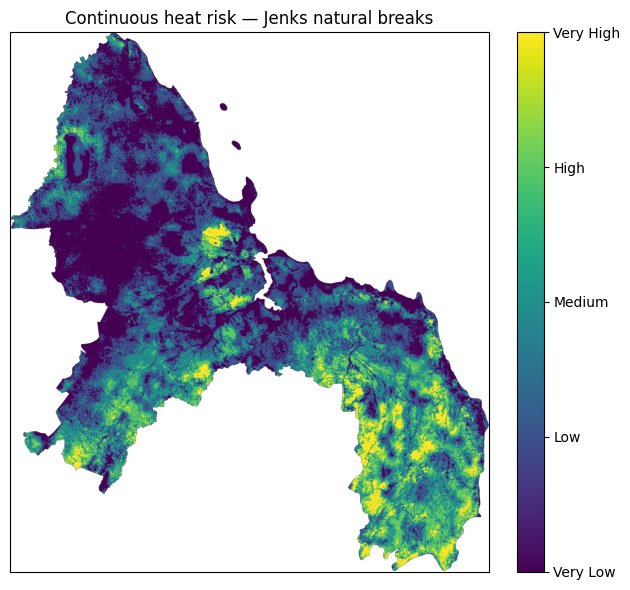


Approximate pixel area: 0.0009000 km²

Percentage of each cluster occupied by each heat-risk class
           Cluster 1  Cluster 2  Cluster 3  Cluster 4
Very Low       68.00      14.28      19.93       3.65
Low            29.85      44.41      33.11      16.23
Medium          2.14      27.81      28.99      34.51
High            0.00      10.17      15.42      32.00
Very High       0.00       3.33       2.56      13.61

Heat-risk distribution table
 Cluster Heat_risk  Pixels  Area_km2  Percentage_within_cluster
       1  Very Low  405037  364.5333                      68.00
       2  Very Low   69826   62.8434                      14.28
       3  Very Low   80261   72.2349                      19.93
       4  Very Low   12821   11.5389                       3.65
       1       Low  177802  160.0218                      29.85
       2       Low  217167  195.4503                      44.41
       3       Low  133369  120.0321                      33.11
       4       Low   57066   51.35

In [32]:
# 6. FIVE JENKS HEAT-RISK CLASSES

risk_values = Risk_r[all_valid].astype(
    "float64"
)

risk_values = risk_values[
    np.isfinite(risk_values)
]

jenks = mc.NaturalBreaks(
    risk_values,
    k=N_RISK_CLASSES,
)

jenks_breaks = jenks.bins

print("\nJenks upper bounds")
for class_id, bound in enumerate(
    jenks_breaks,
    start=1,
):
    print(
        f"  {class_id}: {bound:.6f}"
    )


risk_jenks = np.zeros(
    REF_SHAPE,
    dtype="int32",
)

valid_risk = (
    all_valid
    & np.isfinite(Risk_r)
)

risk_jenks[valid_risk] = (
    jenks.find_bin(
        Risk_r[
            valid_risk
        ].astype("float64")
    ) + 1
).astype("int32")



# Heat-risk class map


plt.figure(figsize=(8, 6))
plt.imshow(
    np.where(
        risk_jenks > 0,
        risk_jenks,
        np.nan,
    ),
    vmin=1,
    vmax=N_RISK_CLASSES,
)

plt.title(
    "Continuous heat risk — Jenks natural breaks"
)
plt.xticks([])
plt.yticks([])

cbar = plt.colorbar(
    ticks=range(
        1,
        N_RISK_CLASSES + 1,
    ),
    fraction=0.046,
    pad=0.04,
)

cbar.set_ticklabels(
    RISK_CLASS_LABELS
)

plt.tight_layout()
plt.show()


# Approximate pixel area

# Analysis grid 30 m
PIXEL_AREA_KM2 = (
    GRID_SIZE_M ** 2
) / 1_000_000

print(
    f"\nApproximate pixel area: "
    f"{PIXEL_AREA_KM2:.7f} km²"
)


# Heat-risk distribution within K=4 profiles

joint_mask = (
    (cluster_raster > 0)
    & (risk_jenks > 0)
)

counts = pd.crosstab(
    risk_jenks[joint_mask],
    cluster_raster[joint_mask],
)

counts = counts.reindex(
    index=range(
        1,
        N_RISK_CLASSES + 1,
    ),
    columns=range(
        1,
        FINAL_K + 1,
    ),
    fill_value=0,
)

counts.index = RISK_CLASS_LABELS
counts.columns = [
    f"Cluster {i}"
    for i in range(
        1,
        FINAL_K + 1,
    )
]

percent = (
    counts.div(
        counts.sum(axis=0),
        axis=1,
    )
    * 100
)

area_km2 = (
    counts
    * PIXEL_AREA_KM2
)

print(
    "\nPercentage of each cluster occupied "
    "by each heat-risk class"
)

print(
    percent.round(2).to_string()
)


# Tidy distribution table

distribution_rows = []

for risk_class_id, risk_label in enumerate(
    RISK_CLASS_LABELS,
    start=1,
):
    for cluster_id in range(
        1,
        FINAL_K + 1,
    ):
        pixels = int(
            counts.loc[
                risk_label,
                f"Cluster {cluster_id}",
            ]
        )

        cluster_total = counts[
            f"Cluster {cluster_id}"
        ].sum()

        distribution_rows.append({
            "Cluster": cluster_id,
            "Heat_risk": risk_label,
            "Pixels": pixels,
            "Area_km2": (
                pixels
                * PIXEL_AREA_KM2
            ),
            "Percentage_within_cluster": (
                100 * pixels / cluster_total
                if cluster_total > 0
                else 0
            ),
        })


distribution_table = pd.DataFrame(
    distribution_rows
)

print(
    "\nHeat-risk distribution table"
)

print(
    distribution_table.round({
        "Area_km2": 4,
        "Percentage_within_cluster": 2,
    }).to_string(index=False)
)


In [33]:
# 7. LEAVE-ONE-INDICATOR-OUT SENSITIVITY

def build_indices_from_dataframe(df):
    """Rebuild H, E and V after removing one indicator."""
    rebuilt = {}

    for group_name, columns in GROUPS.items():
        available = [
            column
            for column in columns
            if column in df.columns
        ]

        if not available:
            raise ValueError(
                f"No indicators remain in "
                f"the {group_name} component."
            )

        component, _ = build_group_index(
            df,
            available,
        )

        rebuilt[group_name] = component

    return (
        rebuilt["Hazard"],
        rebuilt["Exposure"],
        rebuilt["Vulnerability"],
    )


def run_kmeans_profiles(
    H_values,
    E_values,
    V_values,
):
    """
    Rebuild risk and K=4 profiles for one
    leave-one-indicator-out scenario.
    """
    risk_values = (
        H_values
        * E_values
        * V_values
    ).astype("float32")

    X = np.column_stack([
        H_values,
        E_values,
        V_values,
    ]).astype("float32")

    model = KMeans(
        n_clusters=FINAL_K,
        random_state=RANDOM_STATE,
        n_init=10,
        max_iter=MAX_ITERS,
    )

    labels = model.fit_predict(X)

    # Order labels by mean risk so map classes remain stable.
    means = [
        (
            cluster_id,
            risk_values[
                labels == cluster_id
            ].mean(),
        )
        for cluster_id in range(FINAL_K)
    ]

    means.sort(
        key=lambda item: item[1]
    )

    remap = {
        raw_id: new_id + 1
        for new_id, (raw_id, _) in enumerate(
            means
        )
    }

    ordered_labels = np.array(
        [
            remap[label]
            for label in labels
        ],
        dtype="int32",
    )

    return (
        risk_values,
        ordered_labels,
    )


baseline_labels = cluster_classes.copy()

sensitivity_rows = []

for indicator in LAYER_FILES:
    df_loo = df_all.drop(
        columns=[indicator]
    )

    H_loo, E_loo, V_loo = (
        build_indices_from_dataframe(
            df_loo
        )
    )

    _, labels_loo = (
        run_kmeans_profiles(
            H_loo,
            E_loo,
            V_loo,
        )
    )

    ari = adjusted_rand_score(
        baseline_labels,
        labels_loo,
    )

    sensitivity_rows.append({
        "Indicator removed": (
            LAYER_LABELS[indicator]
        ),
        "Indicator_code": indicator,
        "ARI_vs_baseline": ari,
    })


sensitivity_table = (
    pd.DataFrame(sensitivity_rows)
    .sort_values(
        "ARI_vs_baseline"
    )
    .reset_index(drop=True)
)

print(
    "\nLeave-one-indicator-out sensitivity"
)

print(
    sensitivity_table.round(4).to_string(
        index=False
    )
)



Leave-one-indicator-out sensitivity
            Indicator removed               Indicator_code  ARI_vs_baseline
     Land Surface Temperature                          lst           0.4238
                         NDBI                         ndbi           0.4879
           Number of hot days                     hot_days           0.5172
            Distance to parks                   dist_parks           0.7627
        Relative Wealth Index                          rwi           0.7895
 Distance to public transport                 dist_transit           0.8401
Distance to health facilities                  dist_health           0.8834
           Population density           population_density           0.9129
                   Tree cover                   tree_cover           0.9425
 Sensitive population density sensitive_population_density           0.9478
        Distance to the ocean                   dist_water           0.9927


In [34]:
# 8. EXPORT RESULTS

def write_float_raster(
    array,
    filename,
):
    """Write a float GeoTIFF using -9999 as NoData."""
    output = OUTPUT_DIR / filename

    profile = ref_profile.copy()

    profile.update(
        driver="GTiff",
        count=1,
        dtype="float32",
        nodata=-9999.0,
        compress="LZW",
    )

    data = np.asarray(
        array,
        dtype="float32",
    ).copy()

    data[~np.isfinite(data)] = (
        -9999.0
    )

    with rasterio.open(
        output,
        "w",
        **profile,
    ) as dst:
        dst.write(
            data,
            1,
        )

    return output


def write_integer_raster(
    array,
    filename,
):
    """Write an integer GeoTIFF using 0 as NoData."""
    output = OUTPUT_DIR / filename

    profile = ref_profile.copy()

    profile.update(
        driver="GTiff",
        count=1,
        dtype="int32",
        nodata=0,
        compress="LZW",
    )

    with rasterio.open(
        output,
        "w",
        **profile,
    ) as dst:
        dst.write(
            array.astype("int32"),
            1,
        )

    return output


# Raster outputs

outputs = {
    "hazard_index": write_float_raster(
        H_r,
        "hazard_index.tif",
    ),
    "exposure_index": write_float_raster(
        E_r,
        "exposure_index.tif",
    ),
    "vulnerability_index": write_float_raster(
        V_r,
        "vulnerability_index.tif",
    ),
    "continuous_risk": write_float_raster(
        Risk_r,
        "risk_continuous.tif",
    ),
    "kmeans_profiles": write_integer_raster(
        cluster_raster,
        "hev_kmeans_k4_classes.tif",
    ),
    "risk_jenks": write_integer_raster(
        risk_jenks,
        "risk_jenks_5_classes.tif",
    ),
}


print("\nSaved raster outputs")

for name, path in outputs.items():
    print(f"  {name}: {path}")


# Table outputs

weights_path = (
    OUTPUT_DIR
    / "pca_indicator_weights.csv"
)

cluster_path = (
    OUTPUT_DIR
    / "k4_cluster_summary.csv"
)

risk_distribution_path = (
    OUTPUT_DIR
    / "risk_classes_within_clusters.csv"
)

sensitivity_path = (
    OUTPUT_DIR
    / "leave_one_indicator_out_ari.csv"
)

k_selection_path = (
    OUTPUT_DIR
    / "k_selection_results.csv"
)


weights_export = []

for group_name, table in (
    component_weights_tables.items()
):
    temp = table.copy()

    temp.insert(
        0,
        "Component",
        group_name,
    )

    weights_export.append(temp)


pd.concat(
    weights_export,
    ignore_index=True,
).to_csv(
    weights_path,
    index=False,
)

cluster_summary.to_csv(
    cluster_path,
    index=False,
)

distribution_table.to_csv(
    risk_distribution_path,
    index=False,
)

sensitivity_table.to_csv(
    sensitivity_path,
    index=False,
)

k_selection_export = k_selection.merge(
    k_candidates.reset_index(),
    on="K",
    how="left",
)

k_selection_export.to_csv(
    k_selection_path,
    index=False,
)


print("\nSaved table outputs")

for path in [
    weights_path,
    cluster_path,
    risk_distribution_path,
    sensitivity_path,
    k_selection_path,
]:
    print(f"  {path}")



Saved raster outputs
  hazard_index: /content/drive/MyDrive/GIS_Projects/UHI_Dar/machine_learning/all_drivers/drivers/outputs_risk_kmeans/hazard_index.tif
  exposure_index: /content/drive/MyDrive/GIS_Projects/UHI_Dar/machine_learning/all_drivers/drivers/outputs_risk_kmeans/exposure_index.tif
  vulnerability_index: /content/drive/MyDrive/GIS_Projects/UHI_Dar/machine_learning/all_drivers/drivers/outputs_risk_kmeans/vulnerability_index.tif
  continuous_risk: /content/drive/MyDrive/GIS_Projects/UHI_Dar/machine_learning/all_drivers/drivers/outputs_risk_kmeans/risk_continuous.tif
  kmeans_profiles: /content/drive/MyDrive/GIS_Projects/UHI_Dar/machine_learning/all_drivers/drivers/outputs_risk_kmeans/hev_kmeans_k4_classes.tif
  risk_jenks: /content/drive/MyDrive/GIS_Projects/UHI_Dar/machine_learning/all_drivers/drivers/outputs_risk_kmeans/risk_jenks_5_classes.tif

Saved table outputs
  /content/drive/MyDrive/GIS_Projects/UHI_Dar/machine_learning/all_drivers/drivers/outputs_risk_kmeans/pca_indi